In [39]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

In [40]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# MODEL_NAME = "distilbert-base-uncased"
MODEL_NAME = "roberta-base"

In [41]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [42]:
def preprocess_fxn(text):
  return tokenizer(text, truncation=True, padding=True, max_length=256)

In [43]:
data = pd.read_csv("./updated_train.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     7613 non-null   int64 
 1   target         7613 non-null   int64 
 2   complete_text  7613 non-null   object
dtypes: int64(2), object(1)
memory usage: 178.6+ KB


In [44]:
data.drop(columns=['Unnamed: 0'], inplace=True)
data.sample(2)

,target,complete_text
2644,1,destruction so you have a new weapon that can ...
2227,0,deluge the famping things i do for gishwhes ju...


In [45]:
texts = data['complete_text'].tolist()
labels = data['target'].tolist()

In [46]:
max(
    [len(review) for review in texts]
)

159

In [47]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [48]:
train_encoding = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encoding = tokenizer(val_texts, truncation=True, padding=True, max_length=256)

In [49]:
from torch.utils.data import Dataset

In [50]:
class TextDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    item = {
        key: torch.tensor(val[idx]) for key, val in self.encodings.items()
    }

    item['labels'] = torch.tensor(self.labels[idx])
    return item


In [51]:
train_dataset = TextDataset(train_encoding, train_labels)
val_dataset = TextDataset(val_encoding, val_labels)

In [52]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model = model.to(DEVICE)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [53]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

In [56]:
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback

data_collactor = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=15,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=16,
    weight_decay=0.01,
    warmup_ratio=0.1,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    logging_dir="./logs",
    logging_steps=10,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [57]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collactor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [58]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.524615,0.416154,0.829284,0.802731
2,0.436015,0.561011,0.791202,0.776685
3,0.325305,0.396337,0.847669,0.813804
4,0.258753,0.925820,0.769534,0.762677
5,0.196366,0.662709,0.827971,0.789727
6,0.155110,0.776647,0.798424,0.776076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2286, training_loss=0.3424704767900502, metrics={'train_runtime': 456.4207, 'train_samples_per_second': 200.144, 'train_steps_per_second': 12.521, 'total_flos': 1408312201590000.0, 'train_loss': 0.3424704767900502, 'epoch': 6.0})

In [59]:
trainer.evaluate()

{'eval_loss': 0.3982447385787964,
 'eval_accuracy': 0.8483256730137886,
 'eval_f1': 0.8156424581005587,
 'eval_runtime': 2.9497,
 'eval_samples_per_second': 516.324,
 'eval_steps_per_second': 64.752,
 'epoch': 6.0}

In [63]:
test_data = pd.read_csv("./updated_test.csv")
test_data.info()

test_samples = test_data['complete_text'].tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   complete_text  3263 non-null   object
dtypes: object(1)
memory usage: 25.6+ KB


In [61]:
# text = "This movie was amazing!"

inputs = tokenizer(
    test_samples,
    return_tensors="pt",
    truncation=True,
    padding=True
).to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

print(prediction)

tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0')


0    2002
1    1261
Name: count, dtype: int64


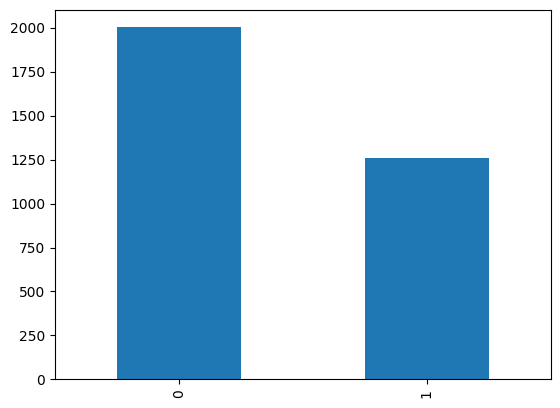

In [62]:
pd.Series(prediction.tolist()).value_counts().plot(kind='bar')
print(pd.Series(prediction.tolist()).value_counts())